## Quantitative Analysis

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import os
print(os.getcwd())

/Commjhub/jupyterhub/home/emch06/comm3180_S26/comm3180_G3_Data_Project/data_analysis/OVERALL


In [5]:
print(os.listdir())

['.ipynb_checkpoints', 'images', 'overall_analysis.ipynb', 'README.md']


## Main Research Question

![](images/illinois.png){width=200}

![](images/penn.jpeg){width=500}

# 1. Which school (UUIC, UPENN) has an overall, stronger return on investment according to post-grad salary, career progression, and school cost? 

#### Components to analyze 
- Quantitative
- median income levels
- overall mobility index
- average salaries for people in that industry (engineering & business and overall)
- ROI (compare median income levels and tuition → seeing if actually worth it)
- Fortune 500, FANG companies 

## Hypothesis:

UPenn offers a higher potential for salary earnings and overall mobility post-graduation, but UUIC offers an overall stronger relative ROI when cost is factored. 

In [6]:
os.getcwd()

'/Commjhub/jupyterhub/home/emch06/comm3180_S26/comm3180_G3_Data_Project/data_analysis/OVERALL'

In [7]:
os.chdir('/Commjhub/jupyterhub/home/emch06/comm3180_S26/comm3180_G3_Data_Project/')

In [8]:
os.getcwd()

'/Commjhub/jupyterhub/home/emch06/comm3180_S26/comm3180_G3_Data_Project'

In [9]:
college_df = pd.read_csv('/Commjhub/jupyterhub/home/emch06/comm3180_S26/comm3180_G3_Data_Project/data/raw/Overall_data/overall.csv')

In [10]:
college_df.columns

Index(['Conference', 'School', 'City', 'State', 'School Type',
       'Undergrad Enrollment', 'Admission Rate', 'Graduation Rate (6-yr)',
       'Median Earnings (10 yrs post-entry)',
       'Median Earnings (6 yrs post-entry)', 'Median Debt at Graduation',
       'Avg Annual Cost (Net Price)', 'SAT Range (25th-75th)'],
      dtype='str')

In [11]:
cleaned_df = college_df.rename(columns={
    "Median Earnings (10 yrs post-entry)": "earnings_6yr",
    "Median Earnings (6 yrs post-entry)": "earnings_10yr"
})

## Median Earnings of schools in Ivy League and Earnings of schools in Big Ten Conference 6 yr and 10 yr post-grad

In [131]:
subset = cleaned_df[["School", "earnings_6yr", "earnings_10yr"]]

In [132]:
subset.head(19)

,School,earnings_6yr,earnings_10yr
0,Harvard University,$97100,$82800
1,Yale University,$91600,$73600
2,Princeton University,$90700,$72400
3,Columbia University,$100700,$82600
4,University of Pennsylvania,$105500,$85900
5,Dartmouth College,$86400,$73200
6,Brown University,$80400,$65900
7,Cornell University,$90700,$74200
8,University of Michigan,$75200,$57300
9,University of Illinois Urbana-Champaign,$66100,$51000


## List of Median Debt at Graduation and Avg Annual Cost (Net Price) 

In [133]:
subset = cleaned_df[["School", "Median Debt at Graduation",
       "Avg Annual Cost (Net Price)"]]

In [134]:
subset.head(19)

,School,Median Debt at Graduation,Avg Annual Cost (Net Price)
0,Harvard University,$12800,$17000
1,Yale University,$11800,$17600
2,Princeton University,$8700,$15500
3,Columbia University,$20500,$18800
4,University of Pennsylvania,$18300,$18300
5,Dartmouth College,$14500,$22600
6,Brown University,$16700,$26000
7,Cornell University,$19500,$28500
8,University of Michigan,$18200,$16800
9,University of Illinois Urbana-Champaign,$19300,$18700


In [20]:
cols = ["earnings_6yr", "earnings_10yr", 
        "Median Debt at Graduation", 
        "Avg Annual Cost (Net Price)"]

for col in cols:
    cleaned_df[col] = (
        cleaned_df[col]
        .replace('[$,]', '', regex=True)  
        .astype(float)
    )

# Return on Investment

In [127]:
cleaned_df["roi_6yr"] = ((cleaned_df["earnings_6yr"] - cleaned_df["Avg Annual Cost (Net Price)"]) / cleaned_df["Avg Annual Cost (Net Price)"]) * 100

In [128]:
cleaned_df.sort_values("roi_6yr", ascending=False)

,Conference,School,City,State,School Type,Undergrad Enrollment,Admission Rate,Graduation Rate (6-yr),earnings_6yr,earnings_10yr,Median Debt at Graduation,Avg Annual Cost (Net Price),SAT Range (25th-75th),roi_10yr,debt_to_income,growth,roi_6yr,value_score
26,Big Ten,University of California Berkeley,Berkeley,CA,Public,31000,11%,93%,75500.0,56100.0,13800.0,11200.0,1310-1530,400.892857,18.278146,-19400.0,574.107143,2.244000
25,Big Ten,University of Washington,Seattle,WA,Public,33400,47%,84%,66200.0,50900.0,17900.0,10800.0,1270-1500,371.296296,27.039275,-15300.0,512.962963,1.773519
2,Ivy League,Princeton University,Princeton,NJ,Private Nonprofit,5500,4%,97%,90700.0,72400.0,8700.0,15500.0,1510-1570,367.096774,9.592062,-18300.0,485.161290,2.991736
4,Ivy League,University of Pennsylvania,Philadelphia,PA,Private Nonprofit,10200,6%,96%,105500.0,85900.0,18300.0,18300.0,1510-1560,369.398907,17.345972,-19600.0,476.502732,2.346995
0,Ivy League,Harvard University,Cambridge,MA,Private Nonprofit,7300,4%,97%,97100.0,82800.0,12800.0,17000.0,1510-1580,387.058824,13.182286,-14300.0,471.176471,2.778523
3,Ivy League,Columbia University,New York,NY,Private Nonprofit,9000,4%,96%,100700.0,82600.0,20500.0,18800.0,1510-1570,339.361702,20.357498,-18100.0,435.638298,2.101781
1,Ivy League,Yale University,New Haven,CT,Private Nonprofit,6600,4%,97%,91600.0,73600.0,11800.0,17600.0,1510-1580,318.181818,12.882096,-18000.0,420.454545,2.503401
12,Big Ten,University of Wisconsin-Madison,Madison,WI,Public,32700,49%,89%,61100.0,47300.0,19800.0,13100.0,1310-1510,261.068702,32.405892,-13800.0,366.412214,1.437690
15,Big Ten,Purdue University,West Lafayette,IN,Public,35000,67%,83%,68400.0,50200.0,20200.0,14700.0,1200-1420,241.496599,29.532164,-18200.0,365.306122,1.438395
22,Big Ten,UCLA,Los Angeles,CA,Public,32400,9%,92%,67800.0,51200.0,14200.0,14600.0,1310-1530,250.684932,20.943953,-16600.0,364.383562,1.777778


In [79]:
cleaned_df["roi_10yr"] = ((cleaned_df["earnings_10yr"] - cleaned_df["Avg Annual Cost (Net Price)"]) / cleaned_df["Avg Annua|l Cost (Net Price)"]) * 100

In [129]:
cleaned_df.sort_values("roi_10yr", ascending=False)

,Conference,School,City,State,School Type,Undergrad Enrollment,Admission Rate,Graduation Rate (6-yr),earnings_6yr,earnings_10yr,Median Debt at Graduation,Avg Annual Cost (Net Price),SAT Range (25th-75th),roi_10yr,debt_to_income,growth,roi_6yr,value_score
26,Big Ten,University of California Berkeley,Berkeley,CA,Public,31000,11%,93%,75500.0,56100.0,13800.0,11200.0,1310-1530,400.892857,18.278146,-19400.0,574.107143,2.244000
0,Ivy League,Harvard University,Cambridge,MA,Private Nonprofit,7300,4%,97%,97100.0,82800.0,12800.0,17000.0,1510-1580,387.058824,13.182286,-14300.0,471.176471,2.778523
25,Big Ten,University of Washington,Seattle,WA,Public,33400,47%,84%,66200.0,50900.0,17900.0,10800.0,1270-1500,371.296296,27.039275,-15300.0,512.962963,1.773519
4,Ivy League,University of Pennsylvania,Philadelphia,PA,Private Nonprofit,10200,6%,96%,105500.0,85900.0,18300.0,18300.0,1510-1560,369.398907,17.345972,-19600.0,476.502732,2.346995
2,Ivy League,Princeton University,Princeton,NJ,Private Nonprofit,5500,4%,97%,90700.0,72400.0,8700.0,15500.0,1510-1570,367.096774,9.592062,-18300.0,485.161290,2.991736
3,Ivy League,Columbia University,New York,NY,Private Nonprofit,9000,4%,96%,100700.0,82600.0,20500.0,18800.0,1510-1570,339.361702,20.357498,-18100.0,435.638298,2.101781
1,Ivy League,Yale University,New Haven,CT,Private Nonprofit,6600,4%,97%,91600.0,73600.0,11800.0,17600.0,1510-1580,318.181818,12.882096,-18000.0,420.454545,2.503401
12,Big Ten,University of Wisconsin-Madison,Madison,WI,Public,32700,49%,89%,61100.0,47300.0,19800.0,13100.0,1310-1510,261.068702,32.405892,-13800.0,366.412214,1.437690
22,Big Ten,UCLA,Los Angeles,CA,Public,32400,9%,92%,67800.0,51200.0,14200.0,14600.0,1310-1530,250.684932,20.943953,-16600.0,364.383562,1.777778
15,Big Ten,Purdue University,West Lafayette,IN,Public,35000,67%,83%,68400.0,50200.0,20200.0,14700.0,1200-1420,241.496599,29.532164,-18200.0,365.306122,1.438395


In [123]:
cleaned_df["debt_to_income"] = cleaned_df["Median Debt at Graduation"] / cleaned_df["earnings_6yr"] * 100

In [124]:
cleaned_df.sort_values("debt_to_income", ascending=False)

,Conference,School,City,State,School Type,Undergrad Enrollment,Admission Rate,Graduation Rate (6-yr),earnings_6yr,earnings_10yr,Median Debt at Graduation,Avg Annual Cost (Net Price),SAT Range (25th-75th),roi_10yr,debt_to_income,growth,roi_6yr,value_score
24,Big Ten,University of Oregon,Eugene,OR,Public,20500,83%,73%,49900.0,39200.0,22000.0,18800.0,1130-1360,108.510638,44.088176,-10700.0,165.425532,0.960784
16,Big Ten,Indiana University Bloomington,Bloomington,IN,Public,33000,80%,80%,54400.0,41900.0,23500.0,13200.0,1170-1390,217.424242,43.198529,-12500.0,312.121212,1.141689
14,Big Ten,Michigan State University,East Lansing,MI,Public,38500,76%,81%,56300.0,43100.0,24100.0,15700.0,1130-1350,174.522293,42.806394,-13200.0,258.598726,1.082915
17,Big Ten,University of Iowa,Iowa City,IA,Public,23000,85%,74%,54800.0,42300.0,22900.0,14400.0,1150-1380,193.750000,41.788321,-12500.0,280.555556,1.134048
10,Big Ten,Pennsylvania State University,University Park,PA,Public,40500,54%,87%,62400.0,46800.0,25800.0,20100.0,1200-1420,132.835821,41.346154,-15600.0,210.447761,1.019608
18,Big Ten,University of Nebraska-Lincoln,Lincoln,NE,Public,20000,78%,68%,53200.0,41000.0,21800.0,14100.0,1130-1360,190.780142,40.977444,-12200.0,277.304965,1.142061
20,Big Ten,Rutgers University–New Brunswick,New Brunswick,NJ,Public,36000,66%,84%,59300.0,45700.0,23000.0,18200.0,1200-1430,151.098901,38.785835,-13600.0,225.824176,1.109223
13,Big Ten,University of Minnesota,Minneapolis,MN,Public,36000,57%,83%,58700.0,45200.0,21300.0,16400.0,1270-1470,175.609756,36.286201,-13500.0,257.926829,1.198939
11,Big Ten,Ohio State University,Columbus,OH,Public,46000,53%,88%,63800.0,48100.0,22400.0,17200.0,1270-1470,179.651163,35.109718,-15700.0,270.930233,1.214646
12,Big Ten,University of Wisconsin-Madison,Madison,WI,Public,32700,49%,89%,61100.0,47300.0,19800.0,13100.0,1310-1510,261.068702,32.405892,-13800.0,366.412214,1.437690


In [125]:
cleaned_df["growth"] = cleaned_df["earnings_10yr"] - cleaned_df["earnings_6yr"]

In [126]:
cleaned_df.sort_values("growth", ascending=False)

,Conference,School,City,State,School Type,Undergrad Enrollment,Admission Rate,Graduation Rate (6-yr),earnings_6yr,earnings_10yr,Median Debt at Graduation,Avg Annual Cost (Net Price),SAT Range (25th-75th),roi_10yr,debt_to_income,growth,roi_6yr,value_score
24,Big Ten,University of Oregon,Eugene,OR,Public,20500,83%,73%,49900.0,39200.0,22000.0,18800.0,1130-1360,108.510638,44.088176,-10700.0,165.425532,0.960784
18,Big Ten,University of Nebraska-Lincoln,Lincoln,NE,Public,20000,78%,68%,53200.0,41000.0,21800.0,14100.0,1130-1360,190.780142,40.977444,-12200.0,277.304965,1.142061
17,Big Ten,University of Iowa,Iowa City,IA,Public,23000,85%,74%,54800.0,42300.0,22900.0,14400.0,1150-1380,193.750000,41.788321,-12500.0,280.555556,1.134048
16,Big Ten,Indiana University Bloomington,Bloomington,IN,Public,33000,80%,80%,54400.0,41900.0,23500.0,13200.0,1170-1390,217.424242,43.198529,-12500.0,312.121212,1.141689
5,Ivy League,Dartmouth College,Hanover,NH,Private Nonprofit,4400,6%,95%,86400.0,73200.0,14500.0,22600.0,1490-1560,223.893805,16.782407,-13200.0,282.300885,1.973046
14,Big Ten,Michigan State University,East Lansing,MI,Public,38500,76%,81%,56300.0,43100.0,24100.0,15700.0,1130-1350,174.522293,42.806394,-13200.0,258.598726,1.082915
13,Big Ten,University of Minnesota,Minneapolis,MN,Public,36000,57%,83%,58700.0,45200.0,21300.0,16400.0,1270-1470,175.609756,36.286201,-13500.0,257.926829,1.198939
20,Big Ten,Rutgers University–New Brunswick,New Brunswick,NJ,Public,36000,66%,84%,59300.0,45700.0,23000.0,18200.0,1200-1430,151.098901,38.785835,-13600.0,225.824176,1.109223
12,Big Ten,University of Wisconsin-Madison,Madison,WI,Public,32700,49%,89%,61100.0,47300.0,19800.0,13100.0,1310-1510,261.068702,32.405892,-13800.0,366.412214,1.437690
0,Ivy League,Harvard University,Cambridge,MA,Private Nonprofit,7300,4%,97%,97100.0,82800.0,12800.0,17000.0,1510-1580,387.058824,13.182286,-14300.0,471.176471,2.778523


In [84]:
sorted_df = cleaned_df.sort_values("roi_6yr")

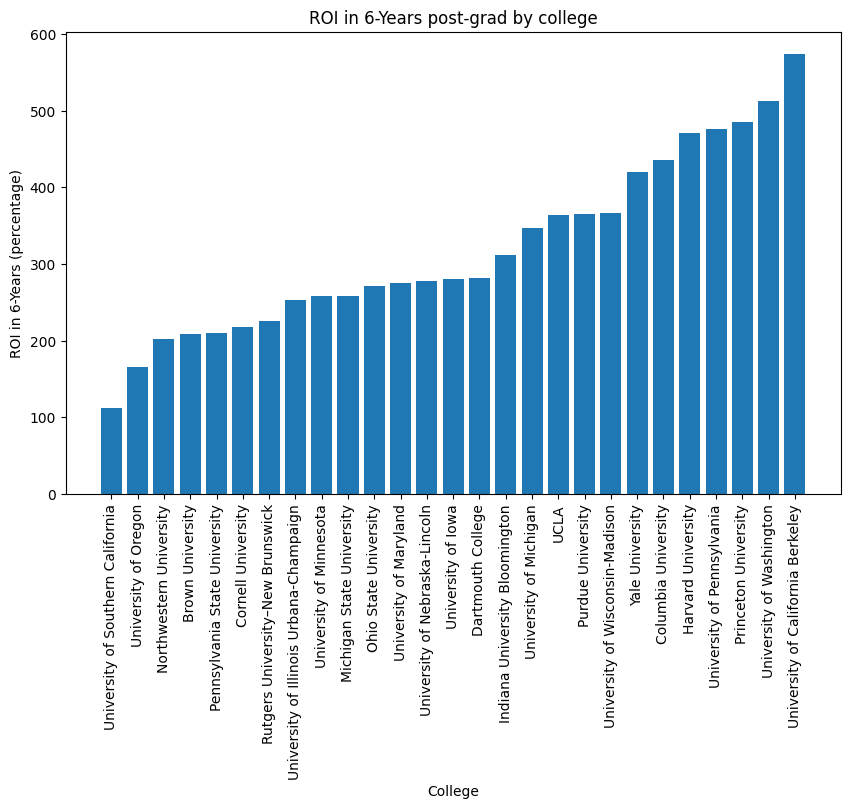

In [88]:
plt.figure(figsize=(10,6))
plt.bar(
    sorted_df["School"], 
    sorted_df["roi_6yr"]
)
plt.xticks(rotation=90)
plt.xlabel("College")
plt.ylabel("ROI in 6-Years (percentage)")
plt.title("ROI in 6-Years post-grad by college")

plt.show()

In [90]:
sorted2_df = cleaned_df.sort_values("roi_10yr")

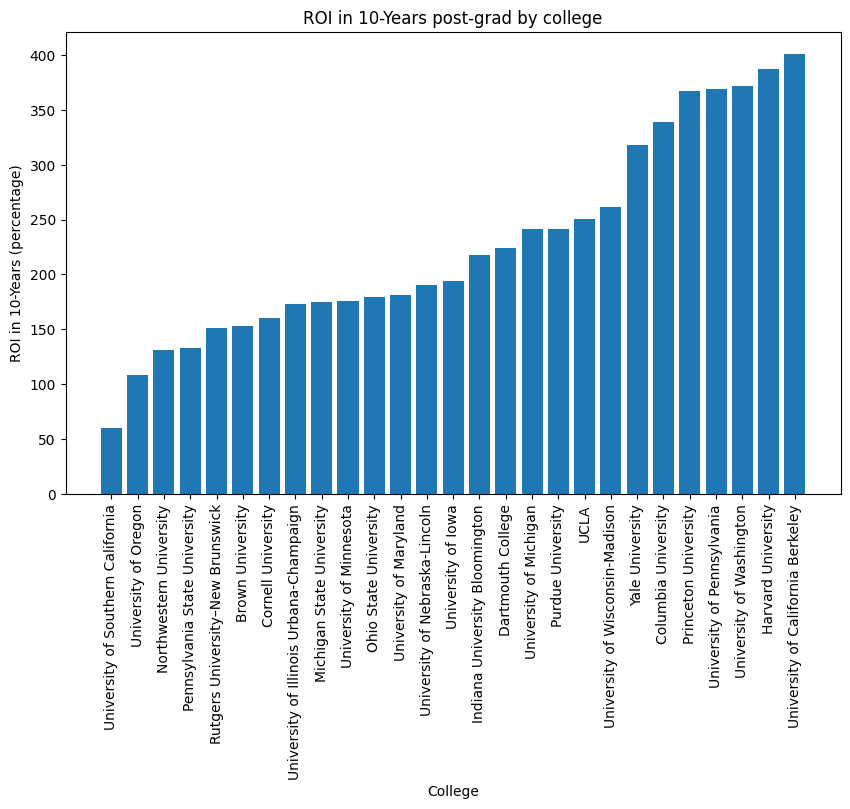

In [91]:
plt.figure(figsize=(10,6))
plt.bar(
    sorted2_df["School"], 
    sorted2_df["roi_10yr"]
)
plt.xticks(rotation=90)
plt.xlabel("College")
plt.ylabel("ROI in 10-Years (percentage)")
plt.title("ROI in 10-Years post-grad by college")

plt.show()

# UPenn vs UIUC

In [131]:
compare = cleaned_df[cleaned_df["School"].isin(["University of Pennsylvania","University of Illinois Urbana-Champaign"])]

In [132]:
compare

,Conference,School,City,State,School Type,Undergrad Enrollment,Admission Rate,Graduation Rate (6-yr),earnings_6yr,earnings_10yr,Median Debt at Graduation,Avg Annual Cost (Net Price),SAT Range (25th-75th),roi_10yr,debt_to_income,growth,roi_6yr,value_score
4,Ivy League,University of Pennsylvania,Philadelphia,PA,Private Nonprofit,10200,6%,96%,105500.0,85900.0,18300.0,18300.0,1510-1560,369.398907,17.345972,-19600.0,476.502732,2.346995
9,Big Ten,University of Illinois Urbana-Champaign,Champaign,IL,Public,35000,45%,85%,66100.0,51000.0,19300.0,18700.0,1270-1500,172.727273,29.198185,-15100.0,253.475936,1.342105


In [133]:
two = compare.set_index("School")[["roi_6yr","roi_10yr"]]

In [134]:
two

,roi_6yr,roi_10yr
School,,
University of Pennsylvania,476.502732,369.398907
University of Illinois Urbana-Champaign,253.475936,172.727273


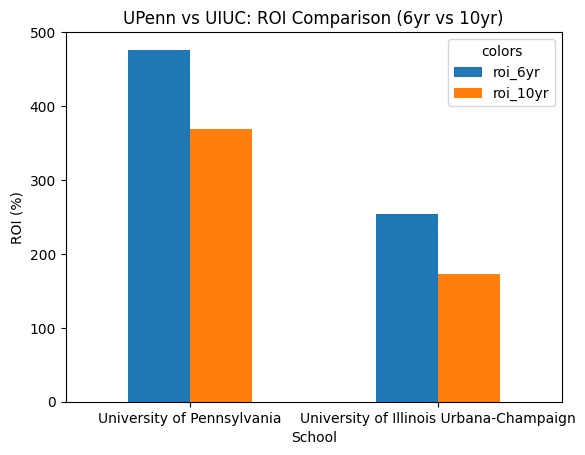

In [118]:
compare.set_index("School")[["roi_6yr", "roi_10yr"]].plot(kind="bar")

plt.title("UPenn vs UIUC: ROI Comparison (6yr vs 10yr)")
plt.ylabel("ROI (%)")
plt.xticks(rotation=0)
plt.legend(title="colors")
plt.show()

In [119]:
another = compare.set_index("School")[["Median Debt at Graduation"]]

In [120]:
another

,Median Debt at Graduation
School,
University of Pennsylvania,18300.0
University of Illinois Urbana-Champaign,19300.0


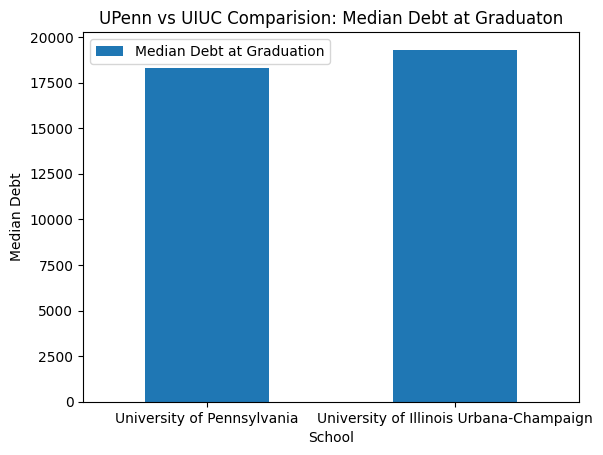

In [122]:
compare.set_index("School")[["Median Debt at Graduation"]].plot(kind="bar")

plt.title("UPenn vs UIUC Comparision: Median Debt at Graduaton")
plt.ylabel("Median Debt")
plt.xticks(rotation=0)
plt.show()

In [135]:
third = compare.set_index("School")[["debt_to_income"]]

In [136]:
third

,debt_to_income
School,
University of Pennsylvania,17.345972
University of Illinois Urbana-Champaign,29.198185


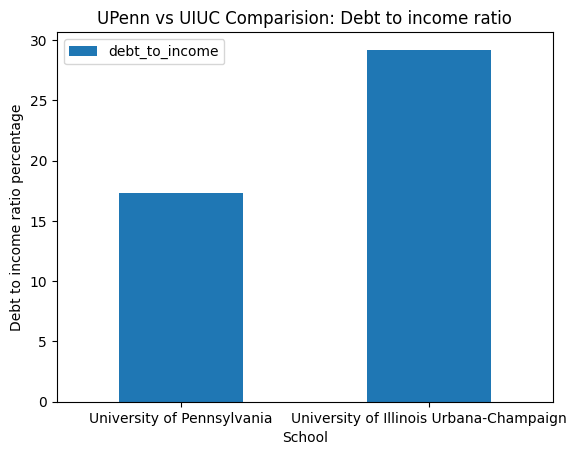

In [138]:
compare.set_index("School")[["debt_to_income"]].plot(kind="bar")

plt.title("UPenn vs UIUC Comparision: Debt to income ratio")
plt.ylabel("Debt to income ratio percentage")
plt.xticks(rotation=0)
plt.show()

# Takeaways

1) Finding #1: Both schools follow the same shape with 6 yr ROI being higher than 10 yr ROI, which is striking because you would expect the income to grow, but this could be because of total costs (tuitions, loans, opportunity cost) compounding more than earning gains do in early career years, compressing ratio. 

2) Finding #2: There is a significant gap between schools. Upenn’s 6yr ROI is nearly double UIUC’ as well as for during 10 year mark. UPenn has dramatically higher median earnings for graduates than UIUC. 

3) Finding #3: Overall debt levels are relatively close. The median debt for Upenn is $18,300 and for UIUC $19,300. Only a difference of 5.5%. UIUC has slightly higher median debt, which could be explained because Upenn has higher overall tuition as well as endowment resources, which can create stronger financial aid. Overall, both figures are both well below the national average of $28,000-$30,000. 


4) Finding #4: While median debt figures were only 5% apart, here UIUC’s ratio of 29.2% is almost 68% higher than Upenn’s 17.3%. UPenn graduates holder a stronger financial position post grad with a 17.3% debt-to-income ratio. UIUC’s 29.2% is extremely higher than the recommended threshold of keeping student debt below 10-15% of the annual income. This can indicate that UIUC students carry more debt relative to what they earn, earning less post-grad. Overall, UIUC students carry more debt. 
